<a href="https://colab.research.google.com/github/valceven/AliacSearchAlgo/blob/master/OneTeamOneGoal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
print("wowza")

wowza


In [2]:
!git clone https://huggingface.co/datasets/seaurkin/facial_exrpressions

Cloning into 'facial_exrpressions'...
remote: Enumerating objects: 9364, done.
remote: Total 9364 (delta 0), reused 0 (delta 0), pack-reused 9364 (from 1)
Receiving objects: 100% (9364/9364), 1.50 MiB | 3.92 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Updating files: 100% (9365/9365), done.
Filtering content: 100% (9363/9363), 17.88 MiB | 117.00 KiB/s, done.


In [1]:
!ls ../content/

sample_data


In [4]:
import tensorflow
from tensorflow import keras
from keras.layers import Dense, GlobalAveragePooling2D, Conv2D, MaxPooling2D
from keras.optimizers import Adam
from keras.models import Model
from keras.applications import ResNet50V2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import pandas as pd
import requests
import os
from tqdm import tqdm
import torch
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [5]:
# check for data if naa ba

dataset_path = "/content/facial_exrpressions/FACS"
labels = os.listdir(dataset_path)
print(labels)

['openmouth', 'kiss', 'smile', 'neutral', 'raisedbrows', 'frowning']


In [6]:
# pre processing the data

# getting the data from the files and adding the path to data dictionary with corresponding labels
data = {"filename": [], "label": []};

# Iterate through each label (subfolder in dataset directory)
for label in labels:
  label_path = os.path.join(dataset_path, label) # Full path to label folder

  # Check if it's a valid directory (avoid files that may exist in dataset_path)
  if os.path.isdir(label_path):
      # Iterate through image files in the label directory
    for file in os.listdir(label_path):
      if file.endswith((".jpg", ".png")):
        # Append the full file path and corresponding label to the dictionary
        data["filename"].append(os.path.join(label_path, file))
        data["label"].append(label);

# converting the data dictionary into a pandas DataFrame for easy processing
df = pd.DataFrame(data)

# Shuffle the dataset to randomize the order of images (ensures even distribution)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head()

# Encode class labels (convert text labels into numerical values) wa ni gi gamit
# from sklearn.preprocessing import LabelEncoder
# encoder = LabelEncoder()
# df["label"] = encoder.fit_transform(df["label"])
# print(df["label"].unique())

# splitting the data into 70% train, 30% temp
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)

# splitting temp data into 50% for validation and 50% for testing
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train: {len(train_df)}")
print(f"Val: {len(val_df)}")
print(f"Test: {len(test_df)}")

Train: 6554
Val: 1404
Test: 1405


In [18]:
# Convert the "label" column to string format
train_df["label"] = train_df["label"].astype(str)
val_df["label"] = val_df["label"].astype(str)
test_df["label"] = test_df["label"].astype(str)

# utilizing preprocess function for resnet model to match training and slightly alter for better training
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)

# preprocessing train_df for valid inputs for resnet model
train_batches = datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="sparse",
    shuffle=True
)

# preprocessing valid_df for valid inputs for resnet model
valid_batches = datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="sparse",
    shuffle=True
)

# preprocessing test_df for valid inputs for resnet model
test_batches = datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="sparse",
    shuffle=False
)

print(f"Train: {len(train_batches)}")
print(f"Val: {len(valid_batches)}")
print(f"Test: {len(test_batches)}")

Found 6554 validated image filenames belonging to 6 classes.
Found 1404 validated image filenames belonging to 6 classes.
Found 1405 validated image filenames belonging to 6 classes.
Train: 205
Val: 44
Test: 44


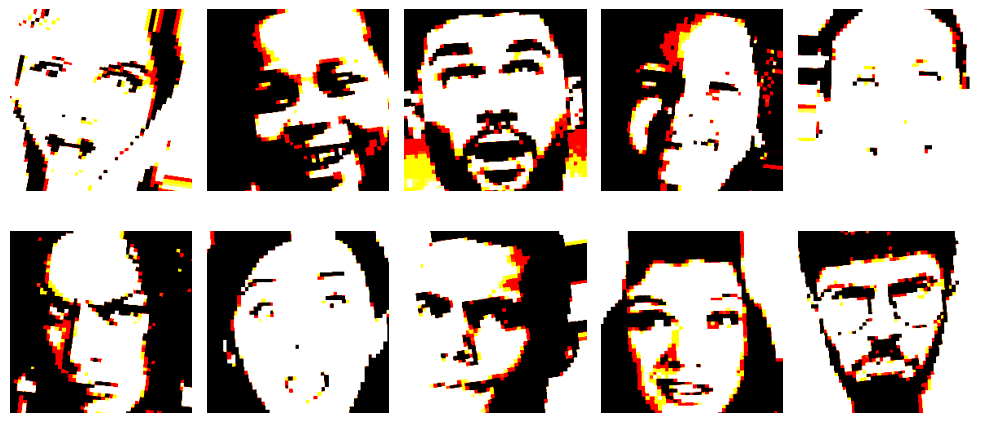

[3. 5. 3. 5. 5.]
[0. 3. 0. 4. 0.]


In [8]:
# check to see how images look like before training them or how they are pre processed.

imgs, lbls = next(train_batches)

def plot_images(arr):
  fig, axes = plt.subplots(2, 5, figsize=(10, 5))
  axes = axes.flatten()
  for img, ax in zip(arr, axes):
    ax.imshow(img)
    ax.axis("off")
  plt.tight_layout()
  plt.show()

plot_images(imgs[:10])
print(lbls[:5])
print(lbls[5:10])

In [9]:
# using ResNet50V2 with the weights included.

base_model = ResNet50V2(weights="imagenet",include_top=False, input_shape=(224, 224, 3))

# base_model unfreezes the idk neurons to learn again and to be specific to our dataset.
base_model.trainable = True

# adding an output class for tailoring it to our datasets or proejcts desired output.
model = base_model.output
model = GlobalAveragePooling2D()(model)
model = Dense(128, activation="relu")(model)
output_layer = Dense(len(labels), activation="softmax")(model)

model = Model(inputs=base_model.input, outputs=output_layer)
model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_conv[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_preact_bn    │ (None, 56, 56, 64)     │            256 │ pool1_pool[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_preact_relu  │ (None, 56, 56, 64)     │              0 │ conv2_block1_preact_b… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,096 │ conv2_block1_preact_r… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_pad        │ (None, 58, 58, 64)     │              0 │ conv2_block1_1_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,864 │ conv2_block1_2_pad[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_preact_r… │
│ (Conv2D)             

 Total params: 23,827,846 (90.90 MB)

 Trainable params: 23,782,406 (90.72 MB)

 Non-trainable params: 45,440 (177.50 KB)

In [10]:
# compile and training, did experiments with the learning rate and this is one of the accuracy we have with the least val_loss
# could've trained more pero di na mo allow among collab na free huhu no money.

model.compile(optimizer=Adam(learning_rate=0.0001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(train_batches, epochs=15, validation_data=valid_batches, batch_size=32)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 213s 765ms/step - accuracy: 0.6987 - loss: 0.8544 - val_accuracy: 0.8967 - val_loss: 0.3133
Epoch 2/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 107s 519ms/step - accuracy: 0.9248 - loss: 0.2214 - val_accuracy: 0.8818 - val_loss: 0.3735
Epoch 3/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 106s 516ms/step - accuracy: 0.9398 - loss: 0.1744 - val_accuracy: 0.9238 - val_loss: 0.2337
Epoch 4/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 106s 516ms/step - accuracy: 0.9456 - loss: 0.1425 - val_accuracy: 0.9309 - val_loss: 0.2215
Epoch 5/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 105s 514ms/step - accuracy: 0.9628 - loss: 0.1101 - val_accuracy: 0.9252 - val_loss: 0.2348
Epoch 6/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 105s 512ms/step - accuracy: 0.9597 - loss: 0.1119 - val_accuracy: 0.9295 - val_loss: 0.2366
Epoch 7/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 108s 524ms/step - accuracy: 0.9615 - loss: 0.1074 - val_accuracy: 0.9352 - val_loss: 0.2271
Epoch 8/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 106s 515ms/step - accuracy: 0.9618 -

In [11]:
model.evaluate(test_batches)

44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 483ms/step - accuracy: 0.9257 - loss: 0.2787


[0.25154420733451843, 0.9309608340263367]

In [12]:
model.save("facial_expression_model.h5")

In [13]:
!ls

from google.colab import files
files.download("facial_expression_model.h5")

facial_expression_model.h5  facial_exrpressions  sample_data


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# for loading the model isntalled.
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
from tensorflow.keras.models import load_model
model_path ='/content/drive/MyDrive/Models/facial_expression_model.h5'

# !ls drive/MyDrive/Models
model = load_model(model_path)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_conv[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_preact_bn    │ (None, 56, 56, 64)     │            256 │ pool1_pool[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_preact_relu  │ (None, 56, 56, 64)     │              0 │ conv2_block1_preact_b… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,096 │ conv2_block1_preact_r… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_pad        │ (None, 58, 58, 64)     │              0 │ conv2_block1_1_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,864 │ conv2_block1_2_pad[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_preact_r… │
│ (Conv2D)             

 Total params: 23,827,848 (90.90 MB)

 Trainable params: 23,782,406 (90.72 MB)

 Non-trainable params: 45,440 (177.50 KB)

 Optimizer params: 2 (12.00 B)

In [19]:
import numpy as np

# Evaluate (correct)
loss, accuracy = model.evaluate(test_batches)
print(f"Test Accuracy (evaluate): {accuracy}")

# Predict (convert probabilities to labels first)
y_pred_probs = model.predict(test_batches)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
y_true = np.array(test_batches.classes)   # Get true labels

# Compute accuracy manually
accuracy_manual = np.mean(y_pred == y_true)
print(f"Test Accuracy (predict): {accuracy_manual * 100:.2f}%")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 365ms/step - accuracy: 0.9312 - loss: 0.2642
Test Accuracy (evaluate): 0.9330961108207703
44/44 ━━━━━━━━━━━━━━━━━━━━ 16s 364ms/step
Test Accuracy (predict): 93.31%


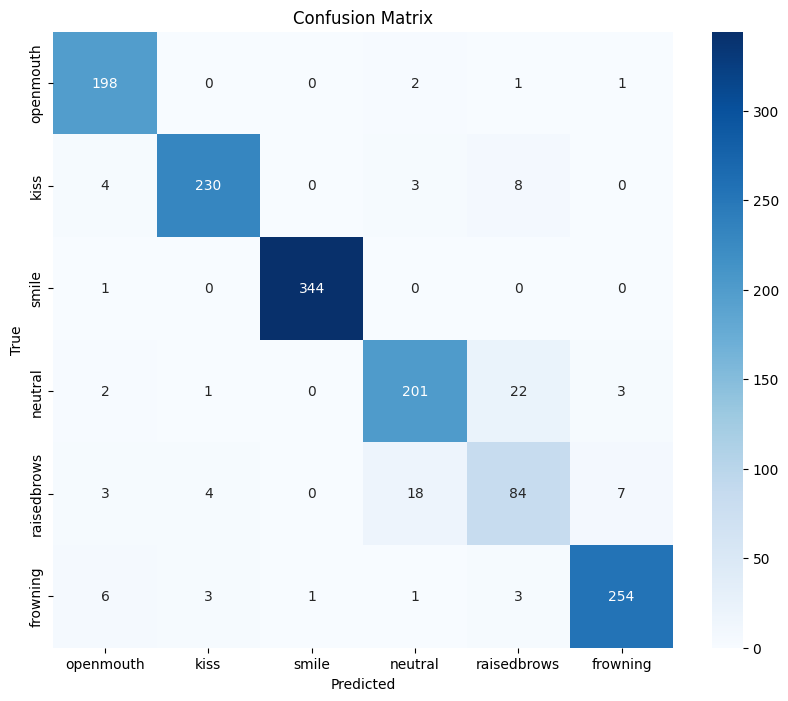

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()